# Impact parameter sign degeneracy


In [1]:
from os import path
import copy
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import collections
from astropy import units as u
from pyLIMA import event
from pyLIMA import telescopes
from pyLIMA.models import PSPL_model, USBL_model
from pyLIMA.outputs import pyLIMA_plots
from pyLIMA.parallax import JPL_ephemerides
from pyLIMA import toolbox
from pyLIMA.fits import DE_fit
from pyLIMA.fits import TRF_fit
from pyLIMA.simulations import simulator
from matplotlib.ticker import MaxNLocator
from pyLIMA.parallax import parallax

Configure a single-lens model 

In [ ]:
sim_event = event.Event(ra=265.0, dec=-17.5)
sim_event.name = 'Sim_event_1'

In [ ]:
tel1 = simulator.simulate_a_telescope(name='tel1', time_start=2459500.0,
                                        time_end=2459750.0, sampling=4,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event.telescopes.append(tel1)
sim_event.check_event()

In [ ]:
#pspl = PSPL_model.PSPLmodel(sim_event, parallax=['None', 0.0], blend_flux_parameter='ftotal')
# t0, u0, tE, fsource, ftotal
#pspl_parameters = [2459651.8548187, -0.004, 200.0, 2500.243993694058444, 2500.243993694058444]

# t0, u0, tE, rho, s, q, alpha, fsource, ftotal
usbl_pos = USBL_model.USBLmodel(sim_event, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl_pos_parameters = [2459651.8548187, 0.005, 20.0, 0.00001, 0.113947, 0.383817, 0.0, 2500.243993694058444, 2500.243993694058444]

usbl_neg = USBL_model.USBLmodel(sim_event, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl_neg_parameters = [2459651.8548187, -0.005, 20.0, 0.00001, 0.113947, 0.383817, 0.0, 2500.243993694058444, 2500.243993694058444]

pyLIMA_parameters_pos = usbl_pos.compute_pyLIMA_parameters(usbl_pos_parameters)
pyLIMA_parameters_neg = usbl_neg.compute_pyLIMA_parameters(usbl_neg_parameters)
print(pyLIMA_parameters_pos)

In [ ]:
simulator.simulate_lightcurve(usbl_pos, pyLIMA_parameters_pos)
simulator.simulate_lightcurve(usbl_neg, pyLIMA_parameters_neg)

In [7]:
def generate_model_lightcurve(event_model, pyLIMA_parameters):
    """Calculate the model lightcurve using a simulated telescope object"""
    
    model_telescope = pyLIMA_plots.create_telescopes_to_plot_model(event_model, pyLIMA_parameters)[0]
    
    flux_model = event_model.compute_the_microlensing_model(model_telescope, pyLIMA_parameters)['photometry']
    
    magnitude = toolbox.brightness_transformation.flux_to_magnitude(flux_model)
    
    model_telescope.lightcurve["mag"] = magnitude * u.mag
    
    mask = ~np.isnan(magnitude)
    model_telescope.lightcurve = model_telescope.lightcurve[mask]

    return model_telescope

In [ ]:
def plot_lc(model, pyLIMA_parameters, plot_file, xmin=None, xmax=None):
    """
    Function to plot simulated Roman lightcurves, showing the full extent of the multi-season lightcurve plus 
    an inset box showing a zoom in lightcurve around the event peak. 

    Parameters:
        model  Object  Model object
        pyLIMA_parameters dict  PyLIMA-format parameter set
        plot_file  str    File path for saved PNG plot
        xmin float [optional] Minimum timestamp for x axis 
        xmax float [optional] Maximum timestamp for x axis 
        
    Returns:
        None, output lightcurve saved to plot_file
    """
    PLOT_COLORS = {
    'W149': '#03A66A',
    'Z087': '#2E03A6'
    }
    
    fig, axs = plt.subplots(1, 1, figsize=(10,10))
    
    dt = 2450000.0

    for index,tel in enumerate(model.event.telescopes):
        if tel.lightcurve is not None:
            axs.errorbar(
                tel.lightcurve['time'].value-dt, tel.lightcurve['mag'], yerr=tel.lightcurve['err_mag'], 
                ms=120, ls='none', c=PLOT_COLORS['W149'], label=tel.name
            )
    
    axs.invert_yaxis()
    
    axs.set_xlabel('JD-' + str(dt) + ' [days]', fontsize=20) 
    axs.set_ylabel('Mag', fontsize=20)
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)
    
    axs.grid()
    #axs.legend(fontsize=18)
    
    axs.tick_params(axis='x', labelsize=18)
    axs.tick_params(axis='y', labelsize=18)

    if xmin:
        axs.set_xlim(xmin, xmax)
        
    model_telescope = generate_model_lightcurve(model, pyLIMA_parameters)
    axs.plot(model_telescope.lightcurve['time'].value-dt, model_telescope.lightcurve['mag'], c='black', ls='-', alpha=0.6)
        
    plt.tight_layout()
    
    plt.savefig(plot_file)

In [ ]:
plot_file = './lc_plot_pos.png'
plot_lc(usbl_pos, pyLIMA_parameters_pos, plot_file, xmin=9640, xmax=9670)

plot_file = './lc_plot_neg.png'
plot_lc(usbl_neg, pyLIMA_parameters_neg, plot_file, xmin=9640, xmax=9670)

In [ ]:
def plot_geometry(microlensing_model, model_parameters, plot_file, bokeh_plot=None):
    """Plot the lensing geometry (i.e source trajectory) and the table of best
    parameters.
    :param object fit: a fit object. See the microlfits for more details.
    :param list best_parameters: a list containing the model you want to plot the
    trajectory
    """
    MAX_PLOT_TICKS = 2
    MARKER_SYMBOLS = np.array(
    [['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x'] * 10])

    MARKERS_COLORS = plt.rcParams["axes.prop_cycle"]

    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)

    faketelescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                     pyLIMA_parameters)

    fig_size = [10, 10]
    figure_trajectory = plt.figure(figsize=(fig_size[0], fig_size[1]), dpi=75)

    figure_axes = figure_trajectory.add_subplot(111, aspect=1)
    figure_axes.set_aspect('equal', adjustable='box')
    plt.subplots_adjust(top=0.8, bottom=0.1, left=0.2, right=0.9, wspace=0.1,
                        hspace=0.1)
    if bokeh_plot is not None:

        bokeh_geometry = figure(width=600, height=600, x_range=(-3, 3), y_range=(-3, 3),
                                x_axis_label=r'$$x [\theta_E]$$',
                                y_axis_label=r'$$y [\theta_E]$$')

    else:

        bokeh_geometry = None

    for telescope in faketelescopes:

        if telescope.lightcurve is not None:

            platform = 'Earth'

            if telescope.location == 'Space':

                platform = telescope.name
                linestyle = '--'

            else:

                linestyle = '-'

            #reference_telescope = telescope

            telescope_index = \
                [i for i in range(len(microlensing_model.event.telescopes)) if
                 microlensing_model.event.telescopes[i].name == telescope.name][0]


            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')

            ind_color = telescope_index % len(MARKERS_COLORS.by_key()["color"])
            color = MARKERS_COLORS.by_key()["color"][ind_color]
            figure_axes.plot(source1_trajectory_x, source1_trajectory_y,
                             c=color,
                             label=platform, linestyle=linestyle)

            if bokeh_geometry is not None:

                bokeh_geometry.line(source1_trajectory_x,
                                    source1_trajectory_y,
                                    color=color,
                                    legend_label=platform)

            if source2_trajectory_y is not None:

                figure_axes.plot(source2_trajectory_x, source2_trajectory_y,
                                 c=color, alpha=0.5,
                                 linestyle=linestyle)

                if bokeh_geometry is not None:

                    bokeh_geometry.line(source2_trajectory_x,
                                    source2_trajectory_y,
                                    color=color, alpha=0.5)



            for trajectory in [[source1_trajectory_x, source1_trajectory_y],
                         [source2_trajectory_x, source2_trajectory_y] ]:

                trajectory_x,trajectory_y=trajectory

                if trajectory_x is not None:

                    for ind in [-2, -1, 0, 1, 2]:

                        try:

                            index = np.argmin(
                                np.abs(telescope.lightcurve['time'].value -
                                       (pyLIMA_parameters['t0'] + ind * pyLIMA_parameters['tE'])))
                            sign = np.sign(trajectory_x[index + 1] - trajectory_x[index])
                            derivative = (trajectory_y[index - 1] - trajectory_y[index + 1]) / (
                                    trajectory_x[index - 1] - trajectory_x[index + 1])

                            figure_axes.annotate('',
                                                 xy=(trajectory_x[index], trajectory_y[index]),
                                                 xytext=(trajectory_x[index] - (
                                                         trajectory_x[index + 1] -
                                                         trajectory_x[index]) * 0.001,
                                                         trajectory_y[index] - (
                                                                 trajectory_x[index + 1] -
                                                                 trajectory_x[
                                                                     index]) * 0.001 *
                                                         derivative),
                                                 arrowprops=dict(arrowstyle="->",
                                                                 mutation_scale=35,
                                                                 color=color))

                            if bokeh_geometry is not None:
                                oh = OpenHead(line_color=color, line_width=1)

                                bokeh_geometry.add_layout(Arrow(end=oh,
                                                                x_start=trajectory_x[index],
                                                                y_start=trajectory_y[index],
                                                                x_end=trajectory_x[
                                                                          index] + sign * 0.001,
                                                                y_end=trajectory_y[
                                                                          index] + sign *
                                                                      0.001 * derivative))

                        except IndexError:

                            pass

    if microlensing_model.parallax_model[0] != 'None':

        telescope = faketelescopes[0]
        try:
            origin_t0par_index = np.argmin(
                np.abs(telescope.lightcurve['time'].value -
                       microlensing_model.parallax_model[1]))
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')

        except AttributeError:
            origin_t0par_index = np.argmin(
                np.abs(telescope.astrometry['time'].value -
                       microlensing_model.parallax_model[1]))
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='astrometry')
        # print(telescope.lightcurve['time'].value,
        #      microlensing_model.parallax_model[1],
        #      origin_t0par_index)

        # print(trajectory_x, trajectory_y)
        # import pdb;
        # pdb.set_trace()
        origin_t0par = np.array(
            (source1_trajectory_x[origin_t0par_index],
             source1_trajectory_y[origin_t0par_index]))
        # origin_t0par += 0.1

        piEN = pyLIMA_parameters['piEN']
        piEE = pyLIMA_parameters['piEE']

        EN_trajectory_angle = parallax.EN_trajectory_angle(piEN, piEE)

        plot_angle = -EN_trajectory_angle

        try:

            plot_angle += pyLIMA_parameters['alpha']

        except KeyError:

            pass

        north = [0.1, 0]
        east = [0, 0.1]

        North = [0.105, 0]
        East = [0, 0.105]

        rota_mat = np.array([[np.cos(plot_angle), -np.sin(plot_angle)],
                             [np.sin(plot_angle), np.cos(plot_angle)]])

        east = np.dot(rota_mat, east)
        north = np.dot(rota_mat, north)
        East = np.dot(rota_mat, East)
        North = np.dot(rota_mat, North)

        plt.annotate('',
                     xy=(origin_t0par[0] + east[0], origin_t0par[1] + east[1]),
                     xytext=(origin_t0par[0], origin_t0par[1]),
                     arrowprops=dict(arrowstyle="->", lw=3, alpha=0.5))
        plt.annotate('E', xy=(origin_t0par[0] + East[0], origin_t0par[1] + East[1]),
                     xytext=(origin_t0par[0] + East[0], origin_t0par[1] + East[1]),
                     weight='bold', alpha=0.5, ha='center', va='center',
                     rotation=np.rad2deg(plot_angle))

        plt.annotate('', xy=(
            origin_t0par[0] + north[0], origin_t0par[1] + north[1]),
                     xytext=(origin_t0par[0], origin_t0par[1]),
                     arrowprops=dict(arrowstyle="->", lw=3, alpha=0.5))
        plt.annotate('N',
                     xy=(origin_t0par[0] + North[0], origin_t0par[1] + North[1]),
                     xytext=(
                         origin_t0par[0] + North[0], origin_t0par[1] + North[1]),
                     weight='bold', alpha=0.5, ha='center', va='center',
                     rotation=np.rad2deg(plot_angle))

        if bokeh_geometry is not None:
            bokeh_geometry.add_layout(
                Arrow(end=OpenHead(line_color="grey", line_width=1),
                      x_start=origin_t0par[0], y_start=origin_t0par[1],
                      x_end=origin_t0par[0] + North[0],
                      y_end=origin_t0par[1] + North[1]))
            bokeh_geometry.add_layout(
                Arrow(end=OpenHead(line_color="grey", line_width=1),
                      x_start=origin_t0par[0], y_start=origin_t0par[1],
                      x_end=origin_t0par[0] + East[0],
                      y_end=origin_t0par[1] + East[1]))

    if 'BL' in microlensing_model.model_type():

        from pyLIMA.caustics import binary_caustics

        regime, caustics, cc = \
            binary_caustics.find_2_lenses_caustics_and_critical_curves(
                pyLIMA_parameters['separation'],
                pyLIMA_parameters['mass_ratio'],
                resolution=5000)

        center_of_mass = (pyLIMA_parameters['separation'] *
                          pyLIMA_parameters['mass_ratio'] / (
                1 + pyLIMA_parameters['mass_ratio']))
        plt.scatter(-center_of_mass, 0, s=10, c='k')
        plt.scatter(-center_of_mass + pyLIMA_parameters['separation'], 0, s=10, c='k')

        for count, caustic in enumerate(caustics):

            try:
                figure_axes.plot(caustic.real, caustic.imag, lw=3, c='r')
                figure_axes.plot(cc[count].real, cc[count].imag, '--k')

                if bokeh_geometry is not None:
                    bokeh_geometry.line(caustic.real, caustic.imag,
                                        color='red', line_width=3)
                    bokeh_geometry.line(cc[count].real, cc[count].imag,
                                        line_dash='dashed',
                                        color='black')

            except AttributeError:

                pass

    else:

        figure_axes.scatter(0, 0, s=10, c='r')

        einstein_ring = plt.Circle((0, 0), 1, fill=False, color='k', linestyle='--')
        figure_axes.add_artist(einstein_ring)

        if bokeh_geometry is not None:
            bokeh_geometry.scatter(0, 0, color='red')
            bokeh_geometry.circle(0, 0, radius=1, line_dash='dashed',
                                  line_color='black', fill_color=None)

    for telescope_index, telescope in enumerate(microlensing_model.event.telescopes):

        if telescope.lightcurve is not None:

            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')

            for ind, trajectory in enumerate([[source1_trajectory_x,
                                             source1_trajectory_y],
                               [source2_trajectory_x, source2_trajectory_y]]):

                trajectory_x, trajectory_y = trajectory

                if trajectory_x is not None:

                    if 'rho' in microlensing_model.pyLIMA_standards_dictionnary.keys():

                        rho = pyLIMA_parameters['rho']
                        if ind == 1:
                            rho = pyLIMA_parameters['rho_2']
                    else:

                        rho = 10 ** -5

                    ind_color = telescope_index % len(MARKERS_COLORS.by_key()["color"])
                    color = MARKERS_COLORS.by_key()["color"][ind_color]

                    if ind == 1:

                        patches = [plt.Circle((x, y), rho, edgecolor=color,
                                              facecolor='none',
                                              alpha=0.2) for x, y in
                                   zip(trajectory_x, trajectory_y)]
                    else:

                        patches = [plt.Circle((x, y), rho, color=color,
                                              alpha=0.2) for x, y in
                                   zip(trajectory_x, trajectory_y)]

                        figure_axes.scatter(trajectory_x, trajectory_y,
                                        c=color,
                                        alpha=0.5, label=telescope.name, s=0.1)

                    coll = collections.PatchCollection(patches, match_original=True)

                    figure_axes.add_collection(coll)

                    if bokeh_geometry is not None:
                        bokeh_geometry.circle(trajectory_x, trajectory_y, radius=rho,
                                              color=color,
                                              radius_dimension='max', fill_alpha=0.5)


    # legend = figure_axes.legend(numpoints=1, loc='best', fancybox=True,
    # framealpha=0.5)
    legend = figure_axes.legend(shadow=True, fontsize='large',
                                bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
                                mode="expand", borderaxespad=0, ncol=3, numpoints=1)

    for handle in legend.legend_handles:

        try:

            handle.set_sizes([100])

        except AttributeError:

            pass

    figure_axes.xaxis.set_major_locator(MaxNLocator(5))
    figure_axes.yaxis.set_major_locator(MaxNLocator(5))
    figure_axes.xaxis.get_major_ticks()[0].draw = lambda *args: None
    figure_axes.yaxis.get_major_ticks()[0].draw = lambda *args: None
    figure_axes.xaxis.get_major_ticks()[-1].draw = lambda *args: None
    figure_axes.yaxis.get_major_ticks()[-1].draw = lambda *args: None

    figure_axes.set_xlabel(r'$x(\theta_E)$', fontsize=25)
    figure_axes.set_ylabel(r'$y(\theta_E)$', fontsize=25)
    figure_axes.tick_params(axis='x', labelsize=15)
    figure_axes.tick_params(axis='y', labelsize=15)

    figure_axes.axis([-0.01, 0.01, -0.01, 0.01])
    # figure_axes.axis('scaled')
    # title = microlensing_model.event.name + ' : ' + microlensing_model.model_type
    # figure_trajectory.suptitle(title, fontsize=30 * fig_size[0] / len(title))

    plt.savefig(plot_file)
    
    return figure_trajectory, bokeh_geometry



In [ ]:
plot_file = './caustic_plot_pos.png'
plot_geometry(usbl_pos, usbl_pos_parameters, plot_file)
plot_file = './caustic_plot_neg.png'
plot_geometry(usbl_neg, usbl_neg_parameters, plot_file)

## PSPL models with annual parallax

In [2]:
sim_event_static = event.Event(ra=265.0, dec=-17.5)
sim_event_static.name = 'Sim_event_static'

sim_event_parallax_pos = event.Event(ra=265.0, dec=-17.5)
sim_event_parallax_pos.name = 'Sim_event_parallax_pos'

sim_event_parallax_neg = event.Event(ra=265.0, dec=-17.5)
sim_event_parallax_neg.name = 'Sim_event_parallax_neg'

In [3]:
tel3 = simulator.simulate_a_telescope(name='tel3', time_start=2459500.0,
                                        time_end=2459750.0, sampling=4,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event_static.telescopes.append(tel3)
sim_event_static.check_event()

tel4 = simulator.simulate_a_telescope(name='tel4', time_start=2459500.0,
                                        time_end=2459750.0, sampling=4,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event_parallax_pos.telescopes.append(tel4)
sim_event_parallax_pos.check_event()

tel5 = simulator.simulate_a_telescope(name='tel5', time_start=2459500.0,
                                        time_end=2459750.0, sampling=4,
                                        location='Earth', camera_filter='I',
                                        uniform_sampling=True, astrometry=False)
sim_event_parallax_neg.telescopes.append(tel5)
sim_event_parallax_neg.check_event()

check_event  : Everything looks fine...
check_event  : Everything looks fine...
check_event  : Everything looks fine...


In [10]:
# t0, u0, tE, rho, s, q, alpha, fsource, ftotal
usbl_static = USBL_model.USBLmodel(sim_event_static, parallax=['None', 0.0], blend_flux_parameter='ftotal')
usbl_static_parameters = [2459651.8548187, 0.005, 200.0, 0.00001, 0.113947, 0.383817, 0.0, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_static = usbl_static.compute_pyLIMA_parameters(usbl_static_parameters)

# t0, u0, tE, rho, s, q, alpha, piEN, piEE, fsource, ftotal
usbl_parallax_pos = USBL_model.USBLmodel(sim_event_parallax_pos, parallax=['Full', 2459651.8548187], blend_flux_parameter='ftotal')
usbl_parallax_parameters_pos = [2459651.8548187, 0.005, 200.0, 0.00001, 0.113947, 0.383817, 0.0, 0.2, 0.2, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_parallax_pos = usbl_parallax_pos.compute_pyLIMA_parameters(usbl_parallax_parameters_pos)

# t0, u0, tE, rho, s, q, alpha, piEN, piEE, fsource, ftotal
usbl_parallax_neg = USBL_model.USBLmodel(sim_event_parallax_neg, parallax=['Full', 2459651.8548187], blend_flux_parameter='ftotal')
usbl_parallax_parameters_neg = [2459651.8548187, -0.005, 200.0, 0.00001, 0.113947, 0.383817, 0.0, -0.2, 0.2, 2500.243993694058444, 2500.243993694058444]
pyLIMA_parameters_parallax_neg = usbl_parallax_neg.compute_pyLIMA_parameters(usbl_parallax_parameters_neg)

Parallax(Full) estimated for the telescope tel4: SUCCESS
Parallax(Full) estimated for the telescope tel5: SUCCESS


In [11]:
simulator.simulate_lightcurve(usbl_static, pyLIMA_parameters_static)
simulator.simulate_lightcurve(usbl_parallax_pos, pyLIMA_parameters_parallax_pos)
simulator.simulate_lightcurve(usbl_parallax_neg, pyLIMA_parameters_parallax_neg)

Parallax(Full) estimated for the telescope tel4: SUCCESS
Parallax(Full) estimated for the telescope tel5: SUCCESS


Parallax(Full) estimated for the telescope tel4: SUCCESS
Parallax(Full) estimated for the telescope tel5: SUCCESS


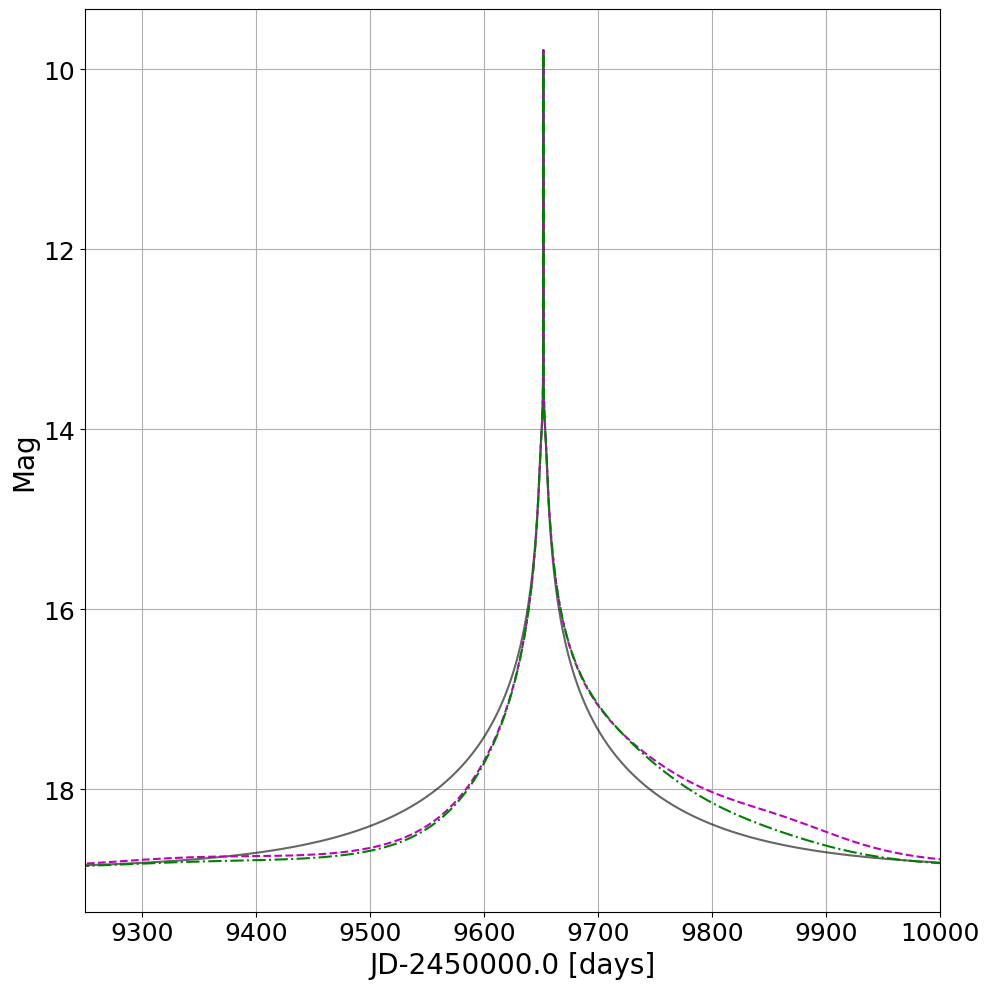

In [12]:
PLOT_COLORS = {
'W149': '#03A66A',
'Z087': '#2E03A6'
}

fig, axs = plt.subplots(1, 1, figsize=(10,10))

dt = 2450000.0

#for index,tel in enumerate(usbl_static.event.telescopes):
#    if tel.lightcurve is not None:
#        axs.errorbar(
#            tel.lightcurve['time'].value-dt, tel.lightcurve['mag'], yerr=tel.lightcurve['err_mag'], 
#            ms=120, ls='none', c=PLOT_COLORS['W149'], label='static'
#        )

#for index,tel in enumerate(usbl_parallax.event.telescopes):
#    if tel.lightcurve is not None:
#        axs.errorbar(
#            tel.lightcurve['time'].value-dt, tel.lightcurve['mag'], yerr=tel.lightcurve['err_mag'], 
#            ms=120, ls='none', c=PLOT_COLORS['Z087'], label='static'
#        )

axs.invert_yaxis()

axs.set_xlabel('JD-' + str(dt) + ' [days]', fontsize=20) 
axs.set_ylabel('Mag', fontsize=20)
axs.tick_params(axis='x', labelsize=18)
axs.tick_params(axis='y', labelsize=18)

axs.grid()
#axs.legend(fontsize=18)

axs.tick_params(axis='x', labelsize=18)
axs.tick_params(axis='y', labelsize=18)

#if xmin:
axs.set_xlim(9250, 10000)
    
model_telescope = generate_model_lightcurve(usbl_static, pyLIMA_parameters_static)
axs.plot(model_telescope.lightcurve['time'].value-dt, model_telescope.lightcurve['mag'], c='black', ls='-', alpha=0.6)
model_telescope = generate_model_lightcurve(usbl_parallax_pos, pyLIMA_parameters_parallax_pos)
axs.plot(model_telescope.lightcurve['time'].value-dt, model_telescope.lightcurve['mag'], c='m', ls='--', alpha=1.0)
model_telescope = generate_model_lightcurve(usbl_parallax_neg, pyLIMA_parameters_parallax_neg)
axs.plot(model_telescope.lightcurve['time'].value-dt, model_telescope.lightcurve['mag'], c='g', ls='-.', alpha=1.0)
    
plt.tight_layout()

plot_file = './udegen_parallax_lc.png'
plt.savefig(plot_file)

Parallax(Full) estimated for the telescope tel4: SUCCESS
Parallax(Full) estimated for the telescope tel5: SUCCESS


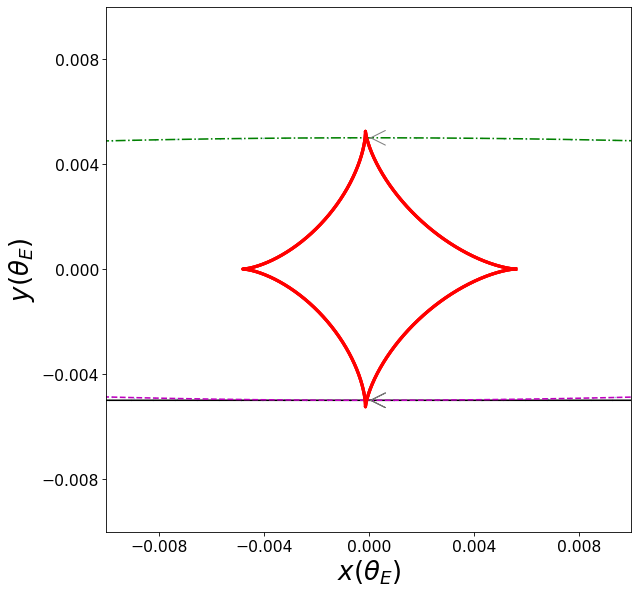

In [13]:
MAX_PLOT_TICKS = 2
MARKER_SYMBOLS = np.array(
[['o', '.', '*', 'v', '^', '<', '>', 's', 'p', 'd', 'x'] * 10])

MARKERS_COLORS = plt.rcParams["axes.prop_cycle"]

LINE_COLORS = ['k', 'm', 'g']
LINE_STYLES = ['-', '--', '-.']

fig_size = [10, 10]
figure_trajectory = plt.figure(figsize=(fig_size[0], fig_size[1]), dpi=75)

figure_axes = figure_trajectory.add_subplot(111, aspect=1)
figure_axes.set_aspect('equal', adjustable='box')
plt.subplots_adjust(top=0.8, bottom=0.1, left=0.2, right=0.9, wspace=0.1,
                    hspace=0.1)

models = {
        usbl_static: usbl_static_parameters, 
        usbl_parallax_pos: usbl_parallax_parameters_pos,
        usbl_parallax_neg: usbl_parallax_parameters_neg
         }

m = -1
for microlensing_model, model_parameters in models.items():
    m += 1
    pyLIMA_parameters = microlensing_model.compute_pyLIMA_parameters(model_parameters)
    
    faketelescopes = pyLIMA_plots.create_telescopes_to_plot_model(microlensing_model,
                                                     pyLIMA_parameters)

    for telescope in faketelescopes:
    
        if telescope.lightcurve is not None:
    
            platform = 'Earth'
    
            if telescope.location == 'Space':
    
                platform = telescope.name
                linestyle = '--'
    
            else:
    
                linestyle = '-'
    
            #reference_telescope = telescope
    
            telescope_index = \
                [i for i in range(len(microlensing_model.event.telescopes)) if
                 microlensing_model.event.telescopes[i].name == telescope.name][0]
    
            # Draw relative lens-source trajectory
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')
    
            ind_color = telescope_index % len(MARKERS_COLORS.by_key()["color"])
            color = MARKERS_COLORS.by_key()["color"][ind_color]
            
            cline = LINE_COLORS[m]
            sline = LINE_STYLES[m]
            figure_axes.plot(source1_trajectory_x, source1_trajectory_y,
                             c=cline,
                             label=platform, linestyle=sline)
                
            if source2_trajectory_y is not None:
    
                figure_axes.plot(source2_trajectory_x, source2_trajectory_y,
                                 c=color, alpha=0.5,
                                 linestyle=linestyle)

            # Draw arrows on lens-source relative trajectory
            for trajectory in [[source1_trajectory_x, source1_trajectory_y],
                         [source2_trajectory_x, source2_trajectory_y] ]:
    
                trajectory_x,trajectory_y=trajectory
    
                if trajectory_x is not None:
    
                    for ind in [-2, -1, 0, 1, 2]:
    
                        try:
    
                            index = np.argmin(
                                np.abs(telescope.lightcurve['time'].value -
                                       (pyLIMA_parameters['t0'] + ind * pyLIMA_parameters['tE'])))
                            sign = np.sign(trajectory_x[index + 1] - trajectory_x[index])
                            derivative = (trajectory_y[index - 1] - trajectory_y[index + 1]) / (
                                    trajectory_x[index - 1] - trajectory_x[index + 1])

                            if len(model_parameters) == 9:
                                arrow_color = 'k'
                            else:
                                arrow_color = 'grey'
                            figure_axes.annotate('',
                                                 xy=(trajectory_x[index], trajectory_y[index]),
                                                 xytext=(trajectory_x[index] - (
                                                         trajectory_x[index + 1] -
                                                         trajectory_x[index]) * 0.001,
                                                         trajectory_y[index] - (
                                                                 trajectory_x[index + 1] -
                                                                 trajectory_x[
                                                                     index]) * 0.001 *
                                                         derivative),
                                                 arrowprops=dict(arrowstyle="->",
                                                                 mutation_scale=35,
                                                                 color=arrow_color))
                                
                        except IndexError:
    
                            pass

    if microlensing_model.parallax_model[0] != 'None':
    
        telescope = faketelescopes[0]
        try:
            origin_t0par_index = np.argmin(
                np.abs(telescope.lightcurve['time'].value -
                       microlensing_model.parallax_model[1]))
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')
    
        except AttributeError:
            origin_t0par_index = np.argmin(
                np.abs(telescope.astrometry['time'].value -
                       microlensing_model.parallax_model[1]))
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='astrometry')
        # print(telescope.lightcurve['time'].value,
        #      microlensing_model.parallax_model[1],
        #      origin_t0par_index)
    
        # print(trajectory_x, trajectory_y)
        # import pdb;
        # pdb.set_trace()
        origin_t0par = np.array(
            (source1_trajectory_x[origin_t0par_index],
             source1_trajectory_y[origin_t0par_index]))
        # origin_t0par += 0.1
    
        piEN = pyLIMA_parameters['piEN']
        piEE = pyLIMA_parameters['piEE']
    
        EN_trajectory_angle = parallax.EN_trajectory_angle(piEN, piEE)
    
        plot_angle = -EN_trajectory_angle
    
        try:
    
            plot_angle += pyLIMA_parameters['alpha']
    
        except KeyError:
    
            pass
    
        north = [0.1, 0]
        east = [0, 0.1]
    
        North = [0.105, 0]
        East = [0, 0.105]
    
        rota_mat = np.array([[np.cos(plot_angle), -np.sin(plot_angle)],
                             [np.sin(plot_angle), np.cos(plot_angle)]])
    
        east = np.dot(rota_mat, east)
        north = np.dot(rota_mat, north)
        East = np.dot(rota_mat, East)
        North = np.dot(rota_mat, North)
    
        plt.annotate('',
                     xy=(origin_t0par[0] + east[0], origin_t0par[1] + east[1]),
                     xytext=(origin_t0par[0], origin_t0par[1]),
                     arrowprops=dict(arrowstyle="->", lw=3, alpha=0.5))
        plt.annotate('E', xy=(origin_t0par[0] + East[0], origin_t0par[1] + East[1]),
                     xytext=(origin_t0par[0] + East[0], origin_t0par[1] + East[1]),
                     weight='bold', alpha=0.5, ha='center', va='center',
                     rotation=np.rad2deg(plot_angle))
    
        plt.annotate('', xy=(
            origin_t0par[0] + north[0], origin_t0par[1] + north[1]),
                     xytext=(origin_t0par[0], origin_t0par[1]),
                     arrowprops=dict(arrowstyle="->", lw=3, alpha=0.5))
        plt.annotate('N',
                     xy=(origin_t0par[0] + North[0], origin_t0par[1] + North[1]),
                     xytext=(
                         origin_t0par[0] + North[0], origin_t0par[1] + North[1]),
                     weight='bold', alpha=0.5, ha='center', va='center',
                     rotation=np.rad2deg(plot_angle))
    
    if 'BL' in microlensing_model.model_type():
    
        from pyLIMA.caustics import binary_caustics
    
        regime, caustics, cc = \
            binary_caustics.find_2_lenses_caustics_and_critical_curves(
                pyLIMA_parameters['separation'],
                pyLIMA_parameters['mass_ratio'],
                resolution=5000)
    
        center_of_mass = (pyLIMA_parameters['separation'] *
                          pyLIMA_parameters['mass_ratio'] / (
                1 + pyLIMA_parameters['mass_ratio']))
        plt.scatter(-center_of_mass, 0, s=10, c='k')
        plt.scatter(-center_of_mass + pyLIMA_parameters['separation'], 0, s=10, c='k')
    
        for count, caustic in enumerate(caustics):
    
            try:
                figure_axes.plot(caustic.real, caustic.imag, lw=3, c='r', ls='-')
                #figure_axes.plot(cc[count].real, cc[count].imag, '--k')
    
            except AttributeError:
    
                pass
    
    else:
    
        figure_axes.scatter(0, 0, s=10, c='r')
    
        einstein_ring = plt.Circle((0, 0), 1, fill=False, color='k', linestyle='--')
        figure_axes.add_artist(einstein_ring)

    for telescope_index, telescope in enumerate(microlensing_model.event.telescopes):
    
        if telescope.lightcurve is not None:
    
            (source1_trajectory_x, source1_trajectory_y,
             source2_trajectory_x, source2_trajectory_y,
             dseparation, dalpha) = microlensing_model.sources_trajectory(
                telescope, pyLIMA_parameters,
                data_type='photometry')
    
            for ind, trajectory in enumerate([[source1_trajectory_x,
                                             source1_trajectory_y],
                               [source2_trajectory_x, source2_trajectory_y]]):
    
                trajectory_x, trajectory_y = trajectory
    
                if trajectory_x is not None:
    
                    if 'rho' in microlensing_model.pyLIMA_standards_dictionnary.keys():
    
                        rho = pyLIMA_parameters['rho']
                        if ind == 1:
                            rho = pyLIMA_parameters['rho_2']
                    else:
    
                        rho = 10 ** -5
    
                    ind_color = telescope_index % len(MARKERS_COLORS.by_key()["color"])
                    color = MARKERS_COLORS.by_key()["color"][ind_color]
    
                    if ind == 1:
    
                        patches = [plt.Circle((x, y), rho, edgecolor=color,
                                              facecolor='none',
                                              alpha=0.2) for x, y in
                                   zip(trajectory_x, trajectory_y)]
                    else:
    
                        patches = [plt.Circle((x, y), rho, color=color,
                                              alpha=0.2) for x, y in
                                   zip(trajectory_x, trajectory_y)]
    
                        figure_axes.scatter(trajectory_x, trajectory_y,
                                        c=color,
                                        alpha=0.5, label=telescope.name, s=0.1)
    
                    coll = collections.PatchCollection(patches, match_original=True)
    
                    figure_axes.add_collection(coll)

# legend = figure_axes.legend(numpoints=1, loc='best', fancybox=True,
# framealpha=0.5)
#legend = figure_axes.legend(shadow=True, fontsize='large',
#                            bbox_to_anchor=(0, 1.02, 1, 0.2), loc="lower left",
#                            mode="expand", borderaxespad=0, ncol=3, numpoints=1)

#for handle in legend.legend_handles:

#    try:

#        handle.set_sizes([100])

#    except AttributeError:

#        pass

figure_axes.xaxis.set_major_locator(MaxNLocator(5))
figure_axes.yaxis.set_major_locator(MaxNLocator(5))
figure_axes.xaxis.get_major_ticks()[0].draw = lambda *args: None
figure_axes.yaxis.get_major_ticks()[0].draw = lambda *args: None
figure_axes.xaxis.get_major_ticks()[-1].draw = lambda *args: None
figure_axes.yaxis.get_major_ticks()[-1].draw = lambda *args: None

figure_axes.set_xlabel(r'$x(\theta_E)$', fontsize=25)
figure_axes.set_ylabel(r'$y(\theta_E)$', fontsize=25)
figure_axes.tick_params(axis='x', labelsize=15)
figure_axes.tick_params(axis='y', labelsize=15)

figure_axes.axis([-0.01, 0.01, -0.01, 0.01])
# figure_axes.axis('scaled')
# title = microlensing_model.event.name + ' : ' + microlensing_model.model_type
# figure_trajectory.suptitle(title, fontsize=30 * fig_size[0] / len(title))

plot_file = './udegen_parallax_caustic_plot.png'
plt.savefig(plot_file)

